In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from matplotlib import image
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon
from matplotlib.patches import Rectangle
import numpy as np
from collections import Counter
from scipy.spatial import cKDTree as KDT
from astropy.table import Column, Table
import itertools
import copy
import scipy.signal
from scipy.spatial import distance
import math
import sys
import pdb
import pickle as pickle
from astropy.convolution import convolve, Gaussian2DKernel
import astropy.coordinates as coord
import astropy.units as u
from astropy.io import ascii
import mpl_scatter_density
from scipy.stats import gaussian_kde, kde
from spisea import synthetic, evolution, atmospheres, reddening, ifmr
from spisea.imf import imf, multiplicity
import pdb
import pylab as py
from flystar import match, transforms, plots, align
from flystar import starlists
from flystar.starlists import StarList
from flystar.startables import StarTable
from astropy.table import Table, Column, vstack
import flystar
import datetime
import copy
import os
import pdb
import time
import warnings
from astropy.utils.exceptions import AstropyUserWarning
from numpy.polynomial.polynomial import polyfit
from astropy.io import fits
from astropy.table import * 
from astropy.modeling import models, fitting

/opt/homebrew/lib/python3.11/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in /Users/devaldeliwala/research/code/SPISEA/models/cdbs/extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


In [3]:
fits_image_filename ='catalogs/dr2/jwst_init_NRCB.fits'
t = Table.read(fits_image_filename, format='fits')

def get_all_filts(t):
    """
    Helper function to get filts in a catalog, regardless of
    masking
    """
    nepochs = len(t['filt'][0])

    # Loop through each time entry and get year
    # from a non-masked source
    filt_arr = []
    for ii in range(nepochs):
        filt_col = t['filt'][:,ii]

        good = np.where(t['x'][:,ii].mask == False)[0]
        if len(good) > 0:
            filt_arr.append(t['filt'][good[0],ii])
        else:
            filt_arr.append(np.nan)
       

    filt_arr = np.array(filt_arr)
   
    return filt_arr

def get_all_dets(t): 
    """
    Helper function to get detectors in a catalog, regardless of
    masking
    """
    nepochs = len(t['det'][0])

    # Loop through each time entry and get year
    # from a non-masked source
    det_arr = []
    for ii in range(nepochs):
        det_col = t['det'][:,ii]

        good = np.where(t['x'][:,ii].mask == False)[0]
        if len(good) > 0:
            det_arr.append(t['det'][good[0],ii])
        else:
            det_arr.append(np.nan)

    det_arr = np.array(det_arr)
   
    return det_arr

def get_matches(t, filt1, det1, filt2, det2): 
    filt = get_all_filts(t)
    det = get_all_dets(t)

    idx1 = np.where( (filt == filt1) & (det == det1) ) 
    idx2 = np.where( (filt == filt2) & (det == det2) ) 

    filt_1 = t['m_orig'][:,idx1]
    filt_2 = t['m_orig'][:,idx2]

    filt_1me = t['me_orig'][:,idx1]
    filt_2me = t['me_orig'][:,idx2]
    
    good = np.where( (filt_1.mask == False) & (filt_2.mask == False) )
    m_filt1_match = filt_1[good]
    m_filt2_match = filt_2[good]
    me_filt1_match = filt_1me[good]
    me_filt2_match = filt_2me[good]

    return m_filt1_match, m_filt2_match, me_filt1_match, me_filt2_match

# All NRCBs between F212N and F115W
N1_f115w_vf212n, N1_f212n_vf115w, N1_f115w_vf212n_me, N1_f212n_vf115w_me = get_matches(t, 'F115W', 'NRCB1', 'F212N', 'NRCB1')
N2_f115w_vf212n, N2_f212n_vf115w, N2_f115w_vf212n_me, N2_f212n_vf115w_me = get_matches(t, 'F115W', 'NRCB2', 'F212N', 'NRCB2')
N3_f115w_vf212n, N3_f212n_vf115w, N3_f115w_vf212n_me, N3_f212n_vf115w_me = get_matches(t, 'F115W', 'NRCB3', 'F212N', 'NRCB3')
N4_f115w_vf212n, N4_f212n_vf115w, N4_f115w_vf212n_me, N4_f212n_vf115w_me = get_matches(t, 'F115W', 'NRCB4', 'F212N', 'NRCB4')

# All NRCB1-4 F212N vs. NRCB5 F323N and F405N
N1_f212n_vN5_f323n, N5_f323n_vN1_f212n, N1_f212n_vN5_f323n_me, N5_f323n_vN1_f212n_me = get_matches(t, 'F212N', 'NRCB1', 'F323N', 'NRCB5')
N2_f212n_vN5_f323n, N5_f323n_vN2_f212n, N2_f212n_vN5_f323n_me, N5_f323n_vN1_f212n_me = get_matches(t, 'F212N', 'NRCB2', 'F323N', 'NRCB5')
N3_f212n_vN5_f323n, N5_f323n_vN3_f212n, N3_f212n_vN5_f323n_me, N5_f323n_vN1_f212n_me = get_matches(t, 'F212N', 'NRCB3', 'F323N', 'NRCB5')
N4_f212n_vN5_f323n, N5_f323n_vN4_f212n, N4_f212n_vN5_f323n_me, N5_f323n_vN1_f212n_me = get_matches(t, 'F212N', 'NRCB4', 'F323N', 'NRCB5')

N1_f212n_vN5_f405n, N5_f405n_vN1_f212n, N1_f212n_vN5_f405n_me, N5_f405n_vN1_f212n_me = get_matches(t, 'F212N', 'NRCB1', 'F405N', 'NRCB5')
N2_f212n_vN5_f405n, N5_f405n_vN2_f212n, N2_f212n_vN5_f405n_me, N5_f405n_vN1_f212n_me = get_matches(t, 'F212N', 'NRCB2', 'F405N', 'NRCB5')
N3_f212n_vN5_f405n, N5_f405n_vN3_f212n, N3_f212n_vN5_f405n_me, N5_f405n_vN1_f212n_me = get_matches(t, 'F212N', 'NRCB3', 'F405N', 'NRCB5')
N4_f212n_vN5_f405n, N5_f405n_vN4_f212n, N4_f212n_vN5_f405n_me, N5_f405n_vN1_f212n_me = get_matches(t, 'F212N', 'NRCB4', 'F405N', 'NRCB5')

N1_f115w_vf212n += 25.92
N2_f115w_vf212n += 25.95
N3_f115w_vf212n += 25.95
N4_f115w_vf212n += 26.09

N1_f212n_vf115w += 22.12
N2_f212n_vf115w += 22.15
N3_f212n_vf115w += 22.15 
N4_f212n_vf115w += 22.23
N1_f212n_vN5_f323n += 22.12
N2_f212n_vN5_f323n += 22.15
N3_f212n_vN5_f323n += 22.15
N4_f212n_vN5_f323n += 22.23
N1_f212n_vN5_f405n += 22.12
N2_f212n_vN5_f405n += 22.15
N3_f212n_vN5_f405n += 22.15
N4_f212n_vN5_f405n += 22.23

N5_f323n_vN1_f212n += 21.14 
N5_f323n_vN2_f212n += 21.14 
N5_f323n_vN3_f212n += 21.14
N5_f323n_vN4_f212n += 21.14

N5_f405n_vN1_f212n += 20.91
N5_f405n_vN2_f212n += 20.91
N5_f405n_vN3_f212n += 20.91
N5_f405n_vN4_f212n += 20.91

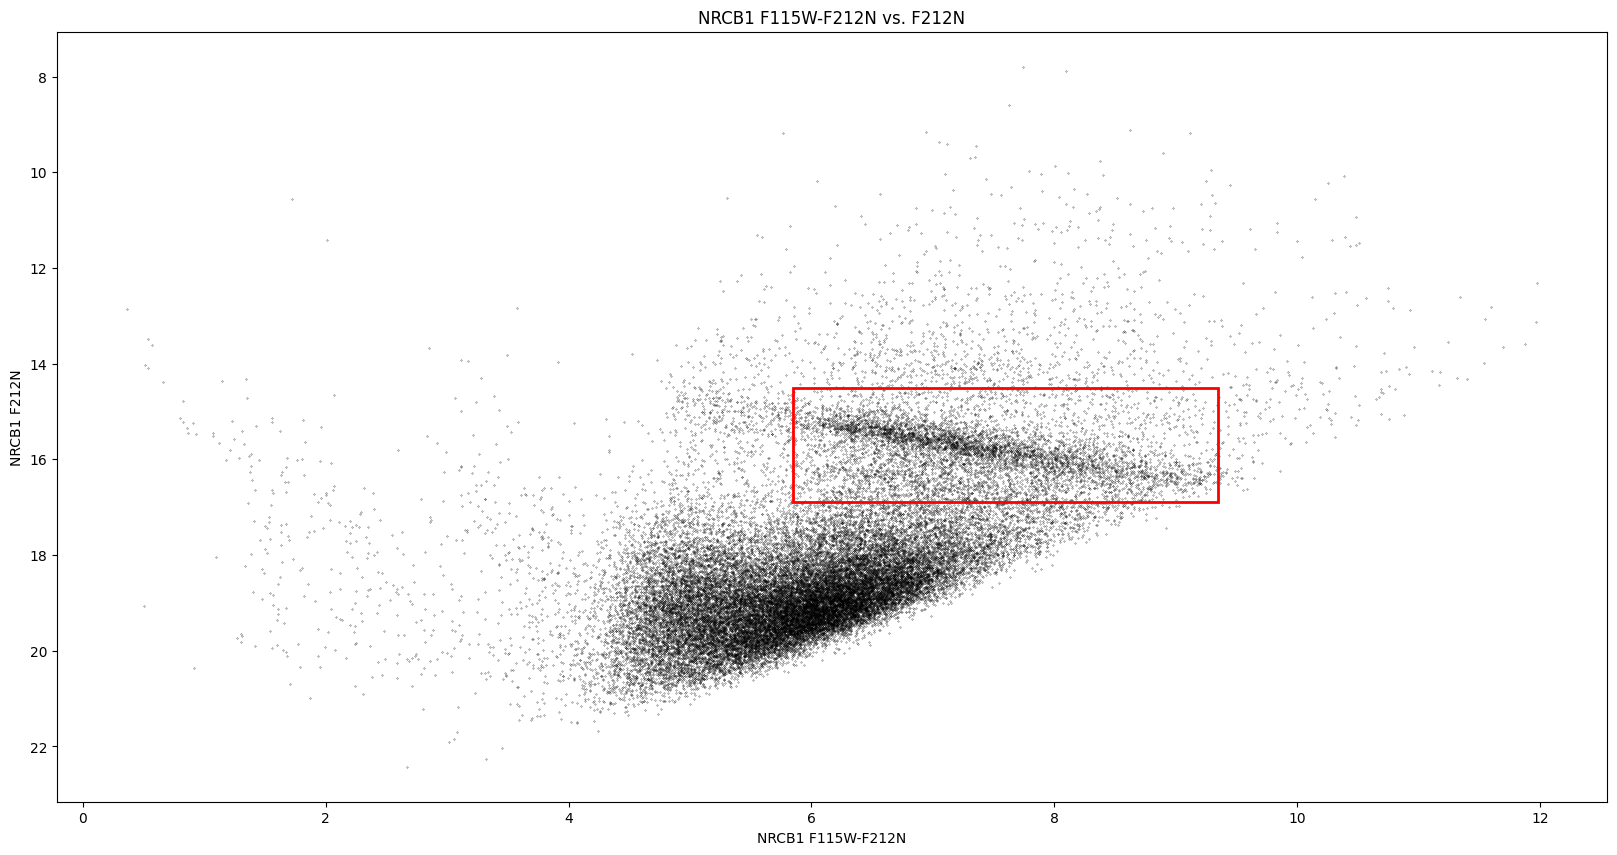

In [4]:
fig, axis = plt.subplots(1,1, figsize = (20, 10))

plt.scatter(np.subtract(N1_f115w_vf212n, N1_f212n_vf115w), N1_f212n_vf115w, c = 'k', s = 0.05)
plt.gca().invert_yaxis()
plt.xlabel('NRCB1 F115W-F212N')
plt.ylabel('NRCB1 F212N')
plt.title('NRCB1 F115W-F212N vs. F212N')

cutoff = Rectangle((5.85, 14.5), 3.5, 2.4, facecolor = (1, 0, 0, 0), lw = 2, ec = (1, 0, 0, 1))
axis.add_patch(cutoff)

x = np.subtract(N1_f115w_vf212n, N1_f212n_vf115w)
y = N1_f212n_vf115w
mag_idxs = []

filt1 = []
filt2 = []

for i in range(len(x)): 
    if x[i] > 5.85 and x[i] < 5.85 + 3.5:
        if y[i] > 14.5 and y[i] < 14.5 + 2.4: 
            mag_idxs.append(i)

for i in mag_idxs: 
    filt1.append(x[i])
    filt2.append(y[i])



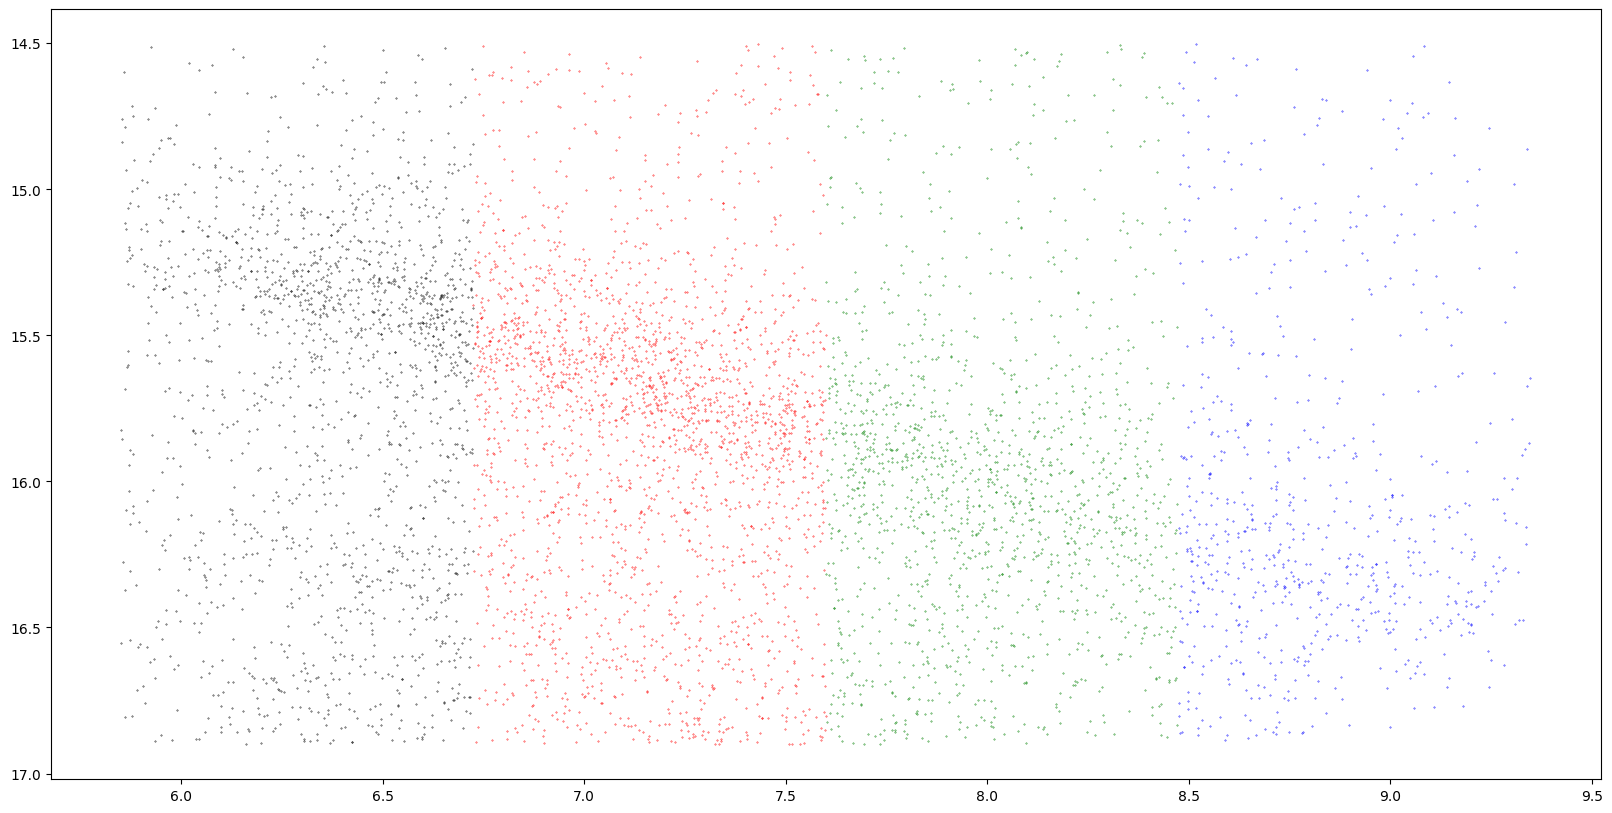

In [5]:
fig, axis = plt.subplots(1,1, figsize = (20, 10))

#plt.scatter(filt1, filt2, c = 'red', s = 0.5)
plt.gca().invert_yaxis()

bin_width = 3.5/4

bin1_x = []
bin2_x = []
bin3_x = []
bin4_x = []
bin1_y = []
bin2_y = []
bin3_y = []
bin4_y = []

for i in range(len(filt1)): 
    if filt1[i] > 5.85 and filt1[i] < 5.85 + bin_width: 
        bin1_x.append(filt1[i])
        bin1_y.append(filt2[i])
    if filt1[i] > 5.85 + bin_width and filt1[i] < 5.85 + 2*bin_width: 
        bin2_x.append(filt1[i])
        bin2_y.append(filt2[i])
    if filt1[i] > 5.85 + 2*bin_width and filt1[i] < 5.85 + 3*bin_width: 
        bin3_x.append(filt1[i])
        bin3_y.append(filt2[i])
    if filt1[i] > 5.85 + 3*bin_width and filt1[i] < 5.85 + 4*bin_width: 
        bin4_x.append(filt1[i])
        bin4_y.append(filt2[i])

plt.scatter(bin1_x, bin1_y, c = 'k', s = 0.1)
plt.scatter(bin2_x, bin2_y, c = 'r', s = 0.1)
plt.scatter(bin3_x, bin3_y, c = 'g', s = 0.1)
plt.scatter(bin4_x, bin4_y, c = 'b', s = 0.1)

(array([ 33.,  38.,  46.,  46.,  82., 176., 206.,  96.]),
 array([14.50357376, 14.80126742, 15.09896107, 15.39665472, 15.69434838,
        15.99204203, 16.28973568, 16.58742934, 16.88512299]),
 <BarContainer object of 8 artists>)

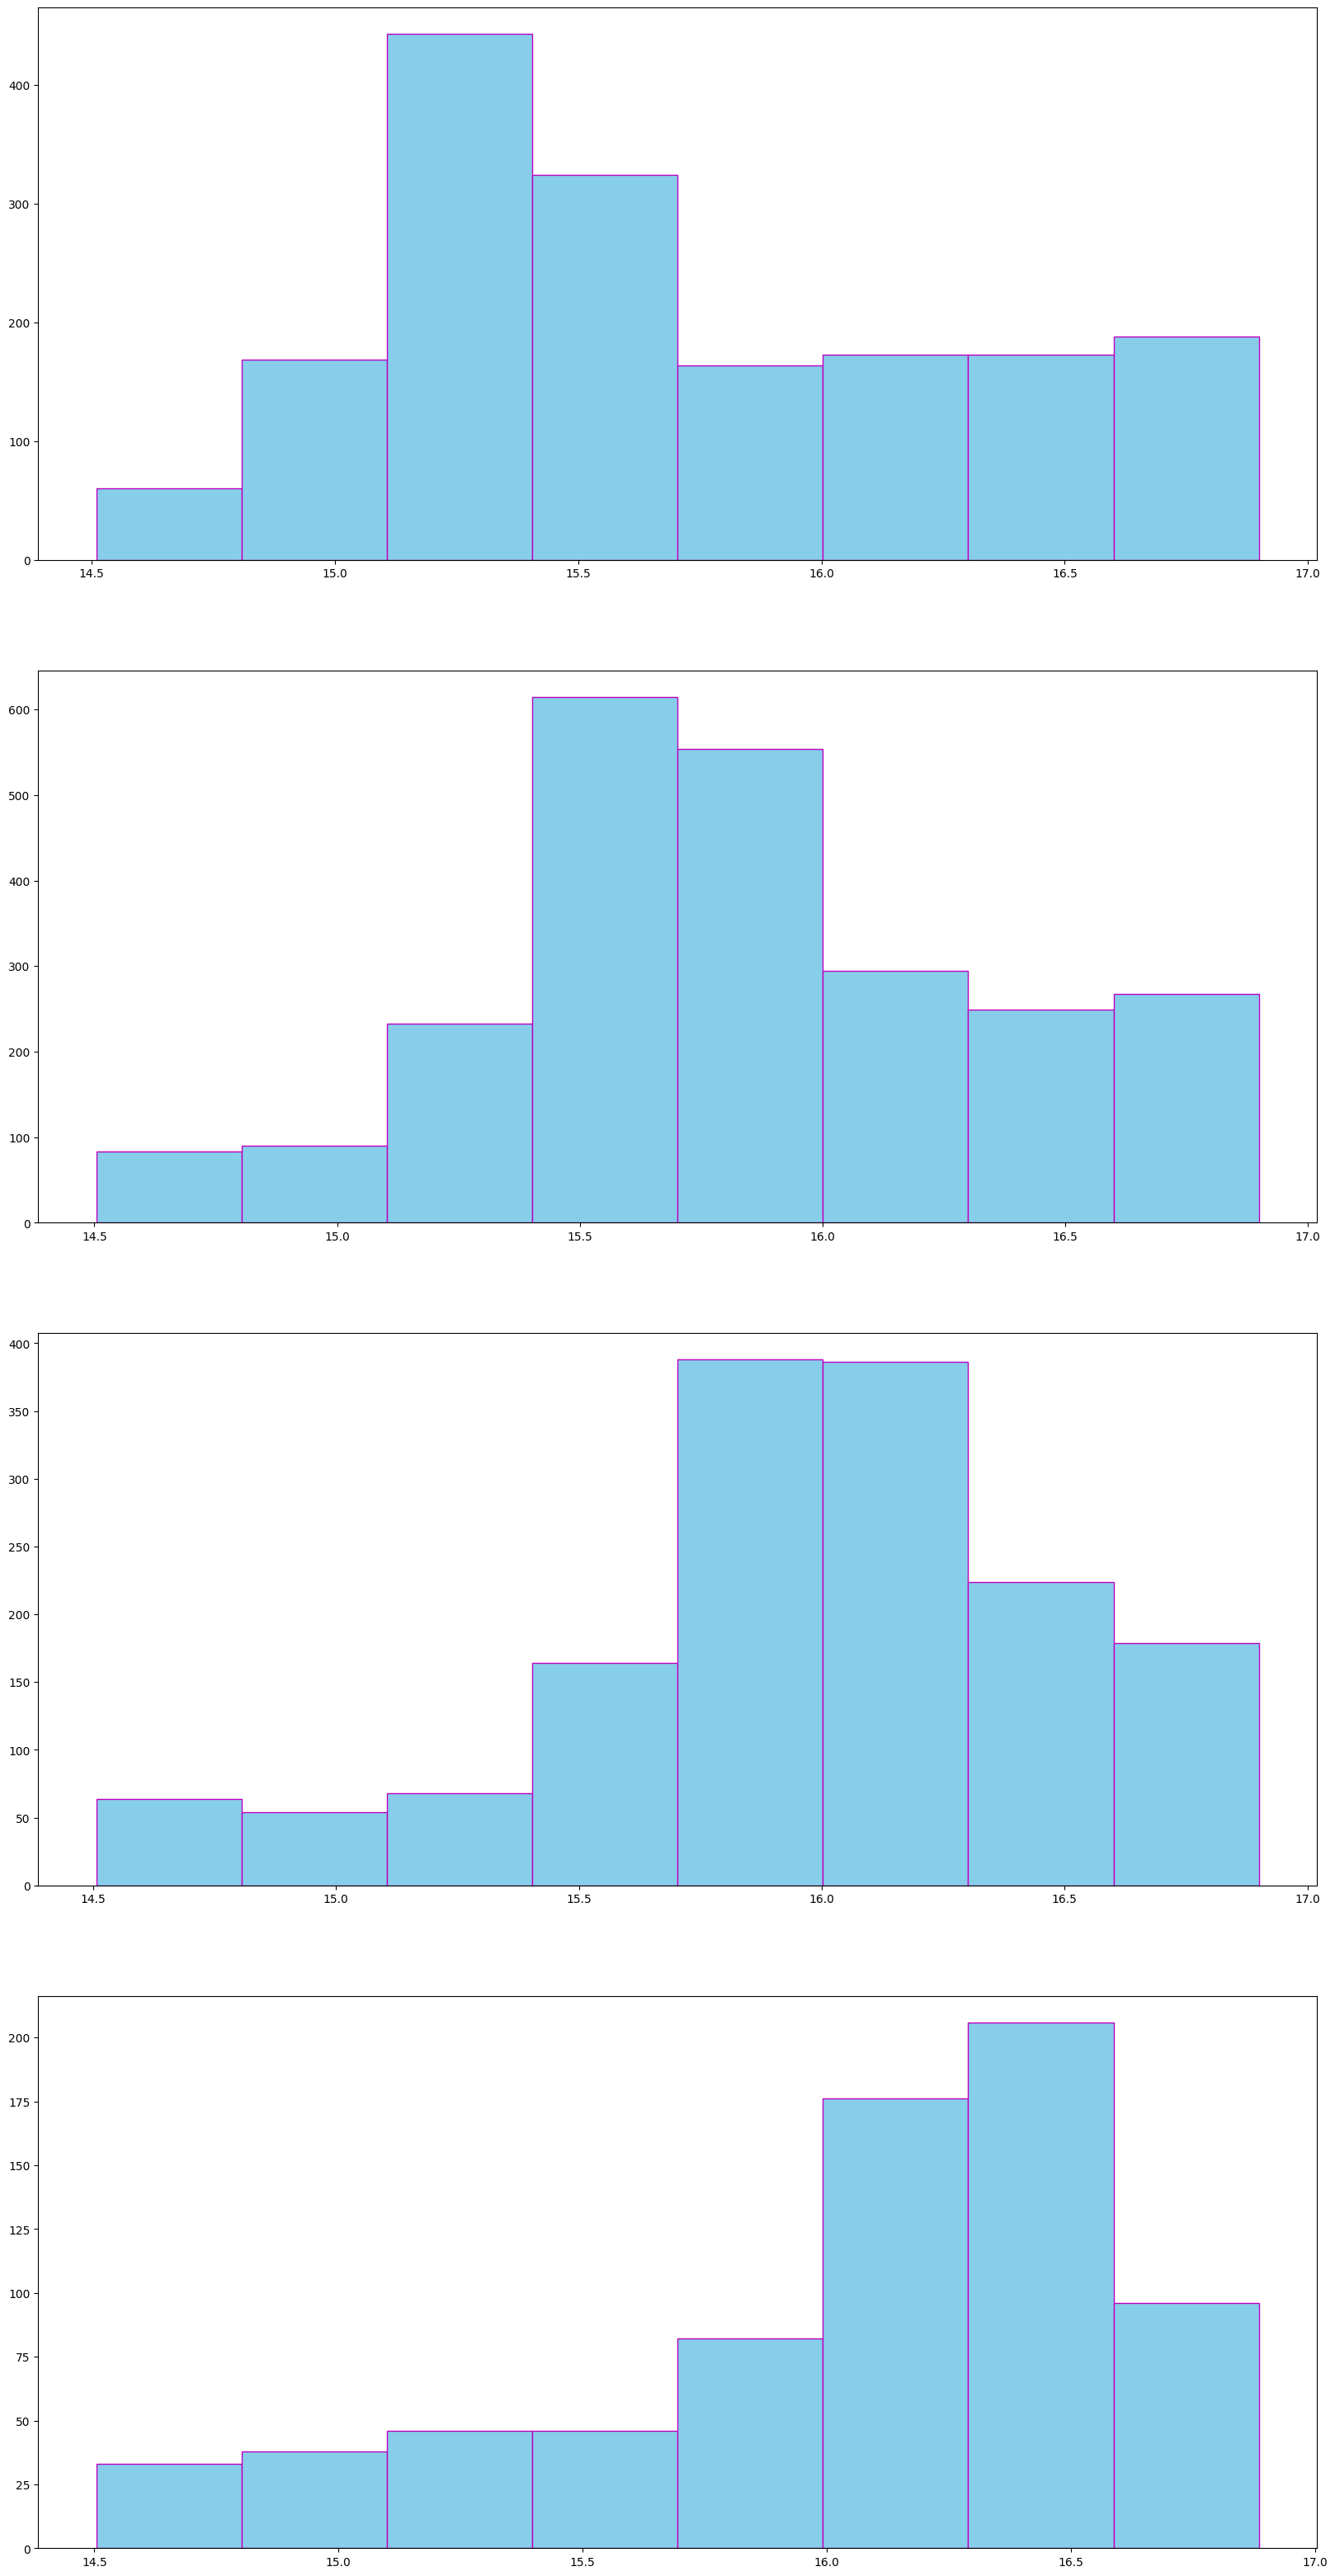

In [6]:
fig, axis = plt.subplots(4,1, figsize = (20,40))

axis[0].hist(bin1_y, bins=8, color='skyblue', edgecolor='m')
axis[1].hist(bin2_y, bins=8, color='skyblue', edgecolor='m')
axis[2].hist(bin3_y, bins=8, color='skyblue', edgecolor='m')
axis[3].hist(bin4_y, bins=8, color='skyblue', edgecolor='m')

(<CompoundModel(amplitude_0=358.67240392, mean_0=15.32297852, stddev_0=0.21956003, slope_1=64.90401957, intercept_1=-890.05445252)>,
 0.005334535108008261)

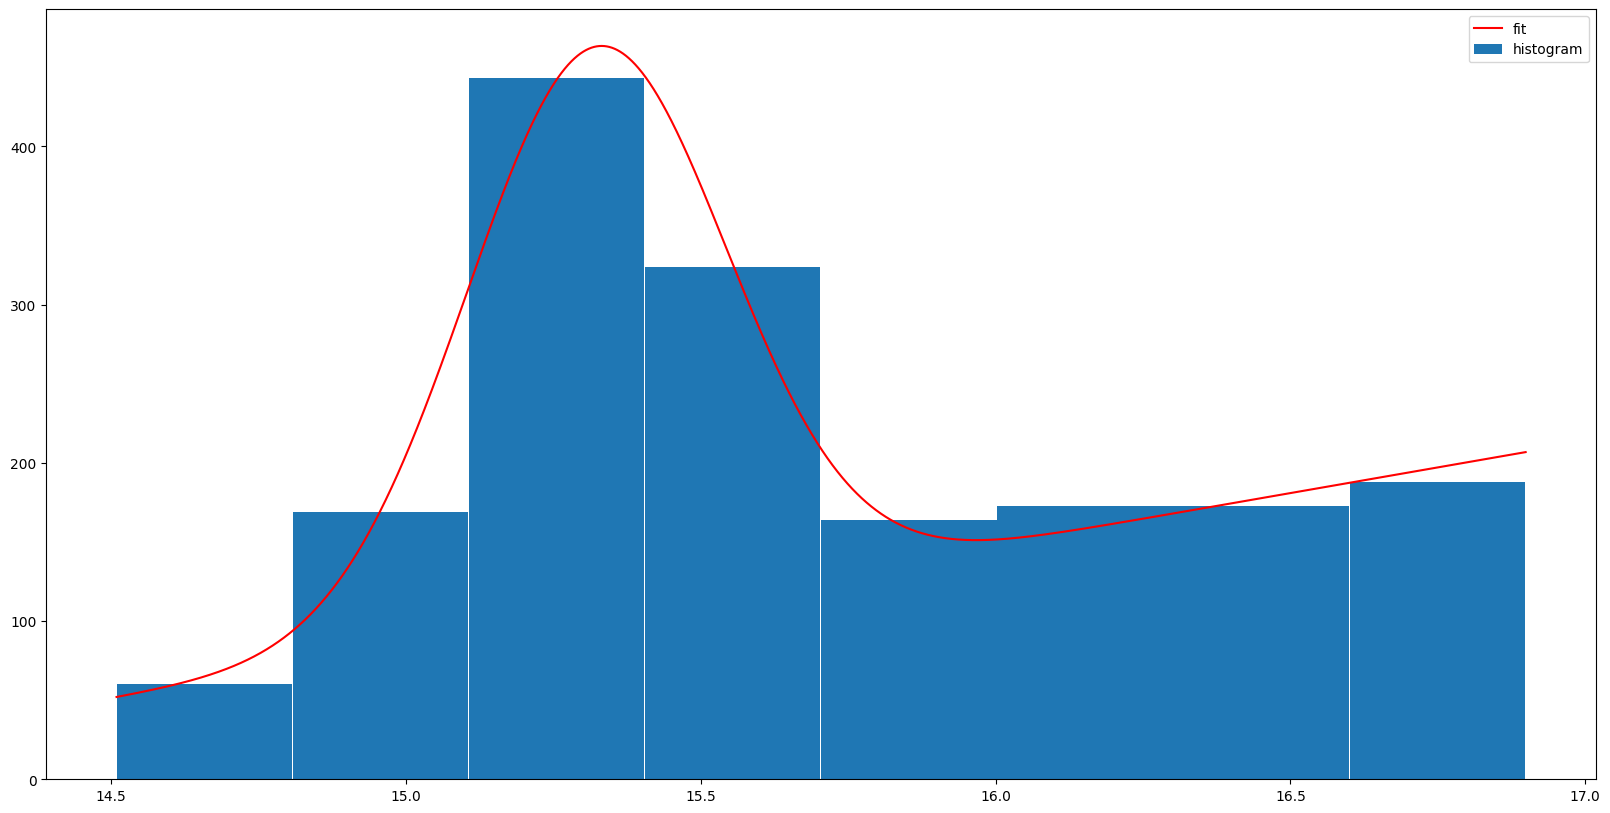

In [30]:
fig, axis = plt.subplots(1, 1, figsize = (20,10))

bin_heights1, bin_borders1 = np.histogram(bin1_y, bins=8)
bin_widths1 = np.diff(bin_borders1)
bin_centers1 = bin_borders1[:-1] + bin_widths1 / 2

t_init1 = models.Gaussian1D(345, 15.57, 0.7)
t_init21 = models.Linear1D(100, 100)
t_initf1 = t_init1 + t_init21

fit_t1 = fitting.LevMarLSQFitter()
t1 = fit_t1(t_initf1, bin_centers1, bin_heights1)

x_interval_for_fit1 = np.linspace(bin_borders1[0], bin_borders1[-1], 10000)
plt.bar(bin_centers1, bin_heights1, width=bin_widths1, label='histogram')
plt.plot(x_interval_for_fit1, t1(x_interval_for_fit1), label='fit', c='red')
plt.legend()

error1 = t1.stddev_0.value / math.sqrt(len(bin1_y))

t1, error1

(<CompoundModel(amplitude_0=507.47263549, mean_0=15.66620914, stddev_0=0.23750673, slope_1=97.07124221, intercept_1=-1352.13851459)>,
 0.004863307509223547)

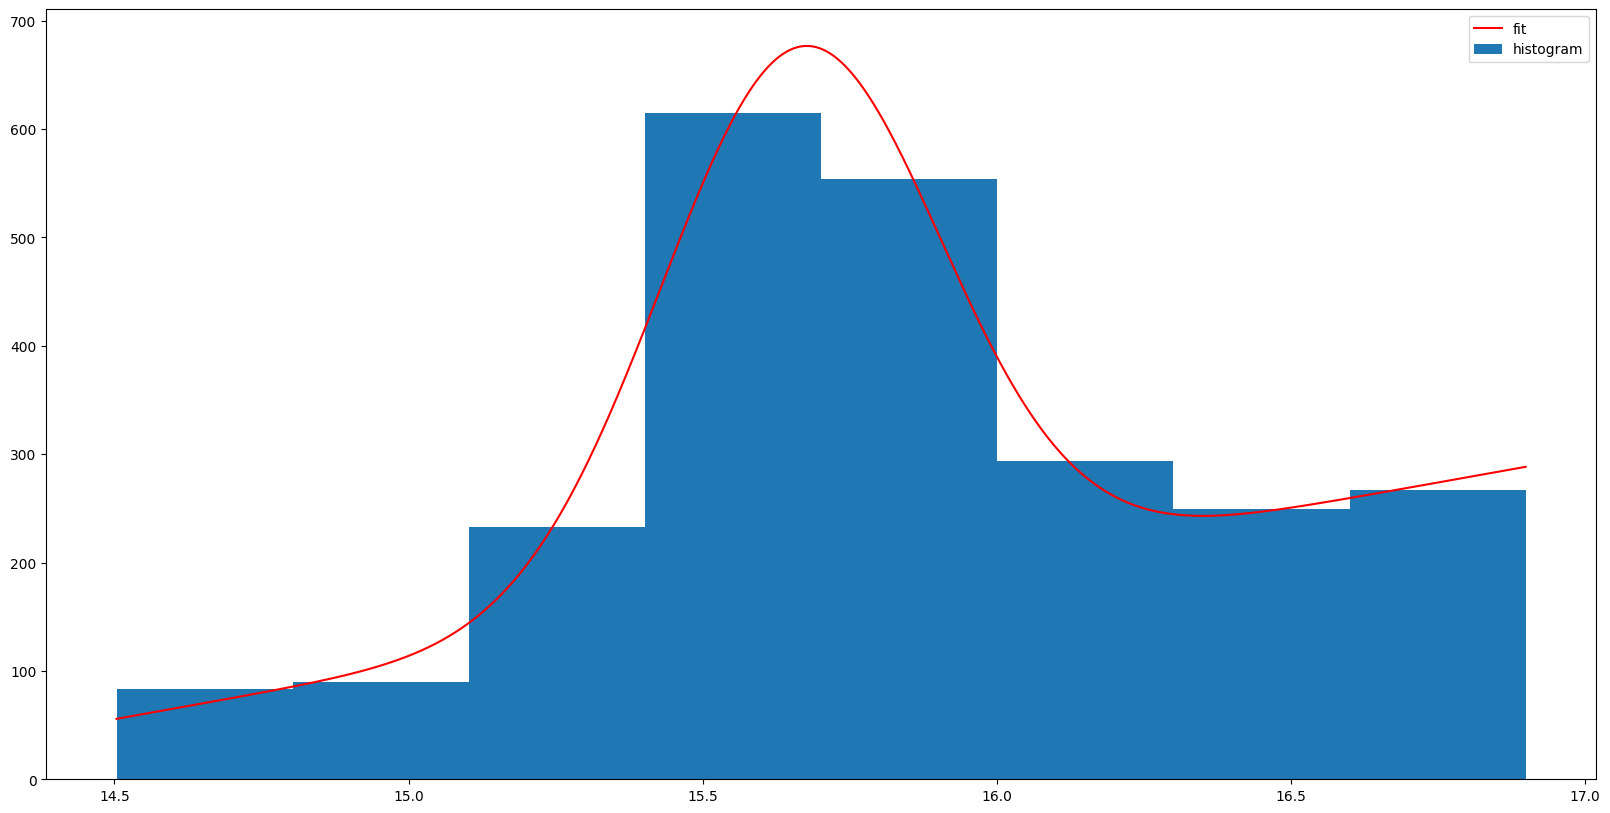

In [25]:
fig, axis = plt.subplots(1, 1, figsize = (20,10))

bin_heights, bin_borders = np.histogram(bin2_y, bins=8)
bin_widths = np.diff(bin_borders)
bin_centers = bin_borders[:-1] + bin_widths / 2

t_init = models.Gaussian1D(536.867, 15.8, 0.52)
t_init2 = models.Linear1D(1, 1)
t_initf = t_init + t_init2

fit_t = fitting.LevMarLSQFitter()
t = fit_t(t_initf, bin_centers, bin_heights)

x_interval_for_fit = np.linspace(bin_borders[0], bin_borders[-1], 10000)
plt.bar(bin_centers, bin_heights, width=bin_widths, label='histogram')
plt.plot(x_interval_for_fit, t(x_interval_for_fit), label='fit', c='red')
plt.legend()

error2 = t.stddev_0.value / math.sqrt(len(bin2_y))

t, error2

(<CompoundModel(amplitude_0=309.88892813, mean_0=15.99411321, stddev_0=0.25402282, slope_1=61.70198951, intercept_1=-860.46909814)>,
 0.006500596610929286)

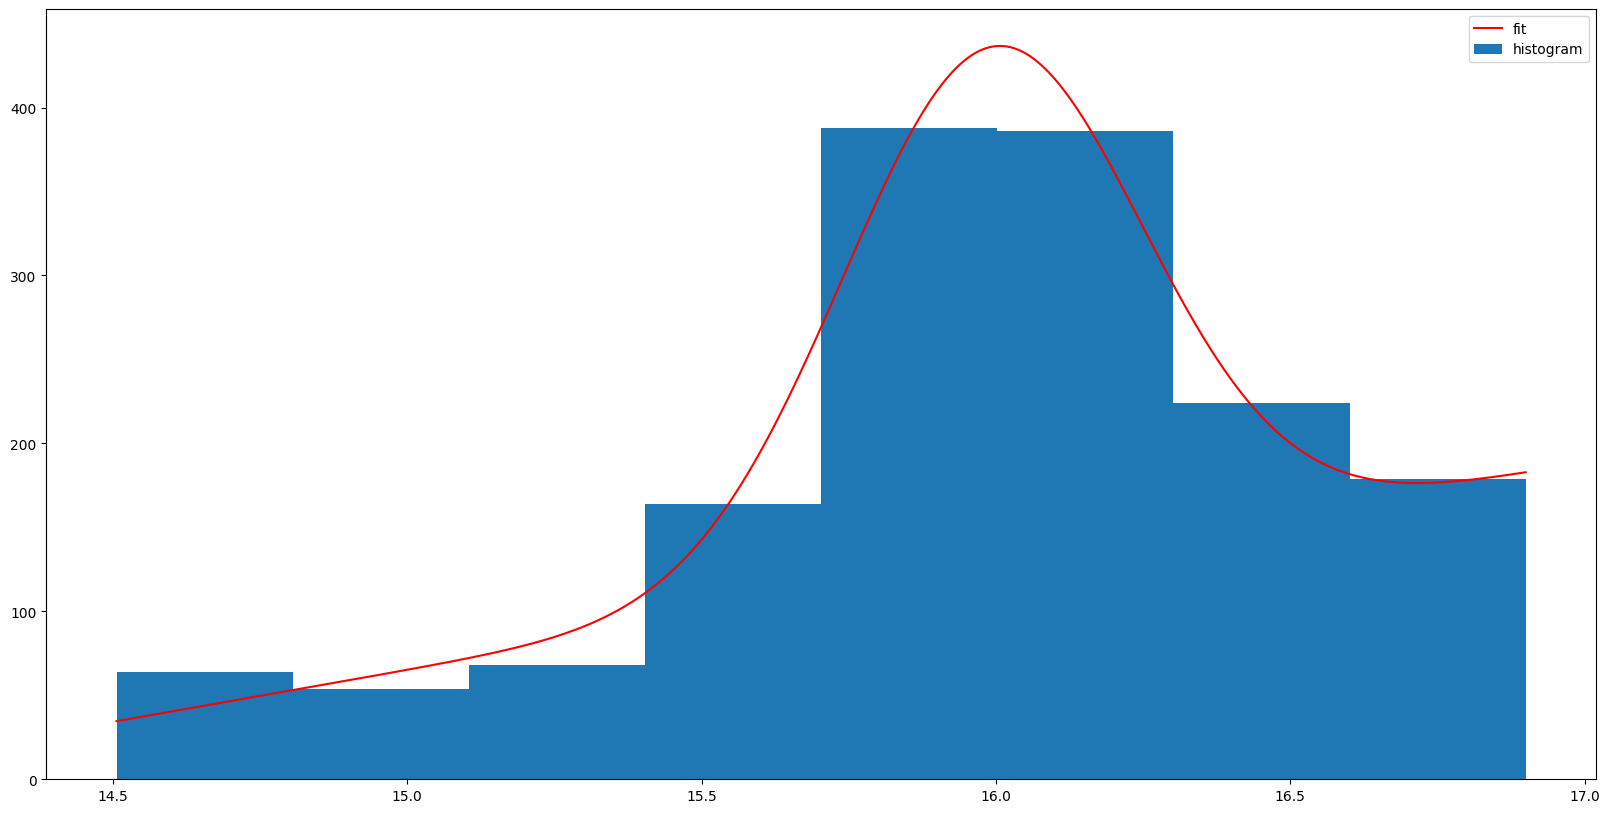

In [26]:
fig, axis = plt.subplots(1, 1, figsize = (20,10))

bin_heights, bin_borders = np.histogram(bin3_y, bins=8)
bin_widths = np.diff(bin_borders)
bin_centers = bin_borders[:-1] + bin_widths / 2

t_init = models.Gaussian1D(309, 16, 0.25)
t_init2 = models.Linear1D(100, 100)
t_initf = t_init + t_init2

fit_t = fitting.LevMarLSQFitter()
t = fit_t(t_initf, bin_centers, bin_heights)

x_interval_for_fit = np.linspace(bin_borders[0], bin_borders[-1], 10000)
plt.bar(bin_centers, bin_heights, width=bin_widths, label='histogram')
plt.plot(x_interval_for_fit, t(x_interval_for_fit), label='fit', c='red')
plt.legend()

error3 = t.stddev_0.value / math.sqrt(len(bin3_y))

t, error3

(<CompoundModel(amplitude_0=164.47706305, mean_0=16.31950577, stddev_0=0.24929053, slope_1=11.26899531, intercept_1=-129.29669891)>,
 0.009271214481594004)

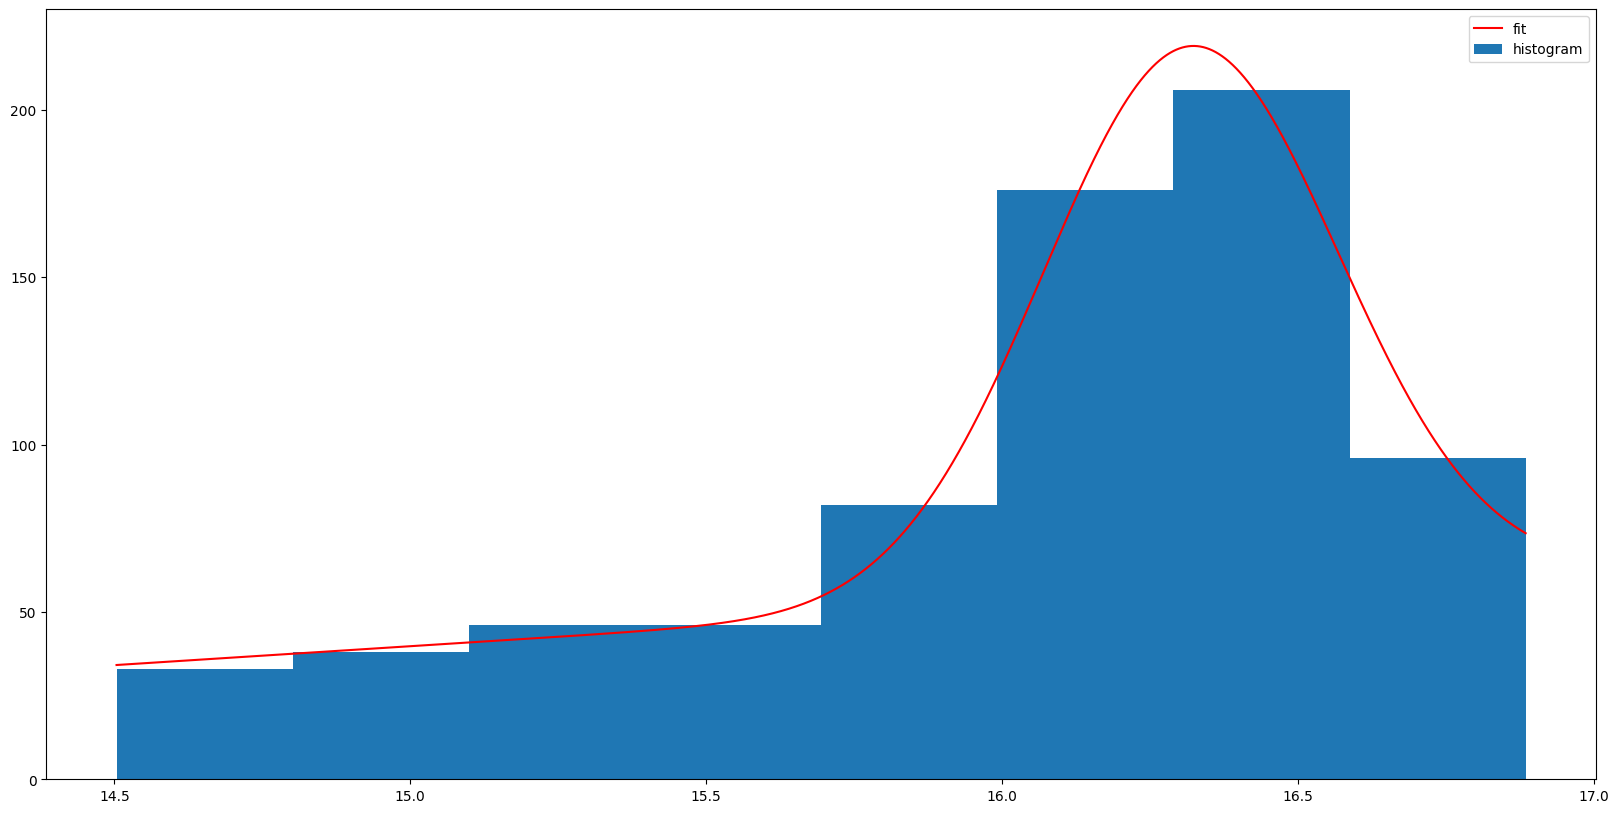

In [27]:
fig, axis = plt.subplots(1, 1, figsize = (20,10))

bin_heights, bin_borders = np.histogram(bin4_y, bins=8)
bin_widths = np.diff(bin_borders)
bin_centers = bin_borders[:-1] + bin_widths / 2

t_init = models.Gaussian1D(164, 16.3, 0.24)
t_init2 = models.Linear1D(100, 100)
t_initf = t_init + t_init2

fit_t = fitting.LevMarLSQFitter()
t = fit_t(t_initf, bin_centers, bin_heights)

x_interval_for_fit = np.linspace(bin_borders[0], bin_borders[-1], 10000)
plt.bar(bin_centers, bin_heights, width=bin_widths, label='histogram')
plt.plot(x_interval_for_fit, t(x_interval_for_fit), label='fit', c='red')
plt.legend()

error4 = t.stddev_0.value / math.sqrt(len(bin4_y))

t, error4

<Linear1D(slope=0.37897143, intercept=12.94531714)>

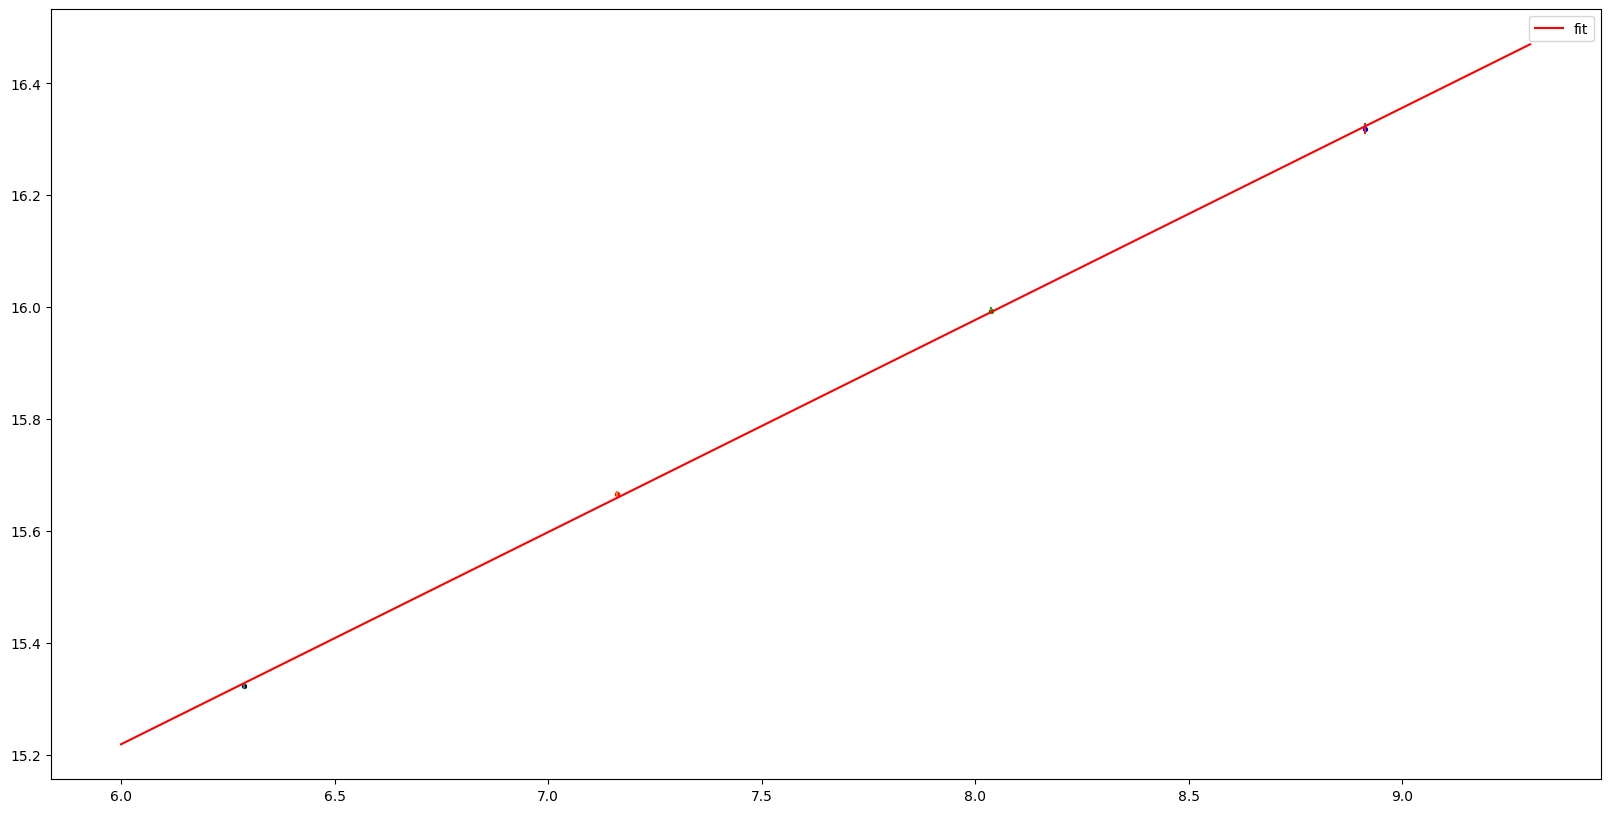

In [29]:
binx1 = (5.85 + 0.5 * bin_width)
binx2 = binx1 + bin_width
binx3 = binx2 + bin_width
binx4 = binx3 + bin_width

fig, axis = plt.subplots(1, 1, figsize = (20, 10))

plt.scatter(binx1, 15.323, c = 'k', s = 8)
plt.scatter(binx2, 15.666, c = 'r', s = 8)
plt.scatter(binx3, 15.994, c = 'g', s = 8)
plt.scatter(binx4, 16.319, c = 'b', s = 8)

plt.errorbar(binx1, 15.323, yerr = error1)
plt.errorbar(binx2, 15.666, yerr = error2)
plt.errorbar(binx3, 15.994, yerr = error3)
plt.errorbar(binx4, 16.319, yerr = error4)

t_init = models.Linear1D(100, 100)
fit_t = fitting.LevMarLSQFitter()
t = fit_t(t_init, [binx1, binx2, binx3, binx4], [15.323, 15.666, 15.994, 16.319])

x_interval_for_fit = np.linspace(6, 9.3, 10000)
plt.plot(x_interval_for_fit, t(x_interval_for_fit), label='fit', c='red')
plt.legend()

t

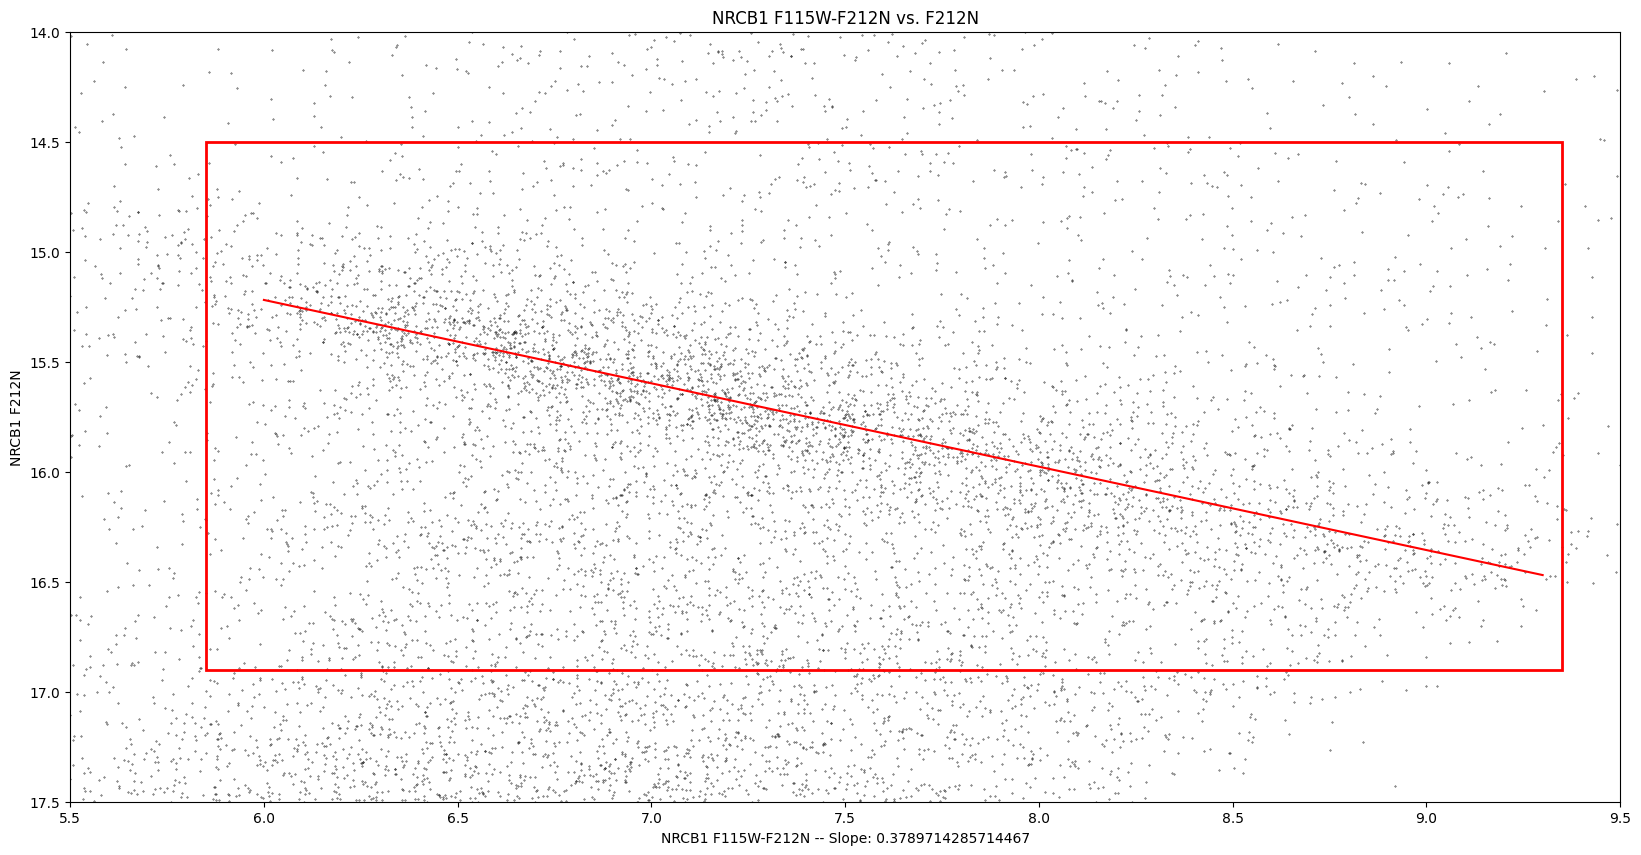

In [43]:
fig, axis = plt.subplots(1,1, figsize = (20, 10))

plt.scatter(np.subtract(N1_f115w_vf212n, N1_f212n_vf115w), N1_f212n_vf115w, c = 'k', s = 0.1)


cutoff = Rectangle((5.85, 14.5), 3.5, 2.4, facecolor = (1, 0, 0, 0), lw = 2, ec = (1, 0, 0, 1))
axis.add_patch(cutoff)

x = np.subtract(N1_f115w_vf212n, N1_f212n_vf115w)
y = N1_f212n_vf115w
mag_idxs = []

filt1 = []
filt2 = []

for i in range(len(x)): 
    if x[i] > 5.85 and x[i] < 5.85 + 3.5:
        if y[i] > 14.5 and y[i] < 14.5 + 2.4: 
            mag_idxs.append(i)

for i in mag_idxs: 
    filt1.append(x[i])
    filt2.append(y[i])

plt.plot(x_interval_for_fit, t(x_interval_for_fit), label='fit', c='r')
plt.xlim(5.5, 9.5)
plt.ylim(17.5, 14)

plt.xlabel(f'NRCB1 F115W-F212N -- Slope: {t.slope.value}')
plt.ylabel('NRCB1 F212N')
plt.title('NRCB1 F115W-F212N vs. F212N')


plt.savefig("bincmd.png")

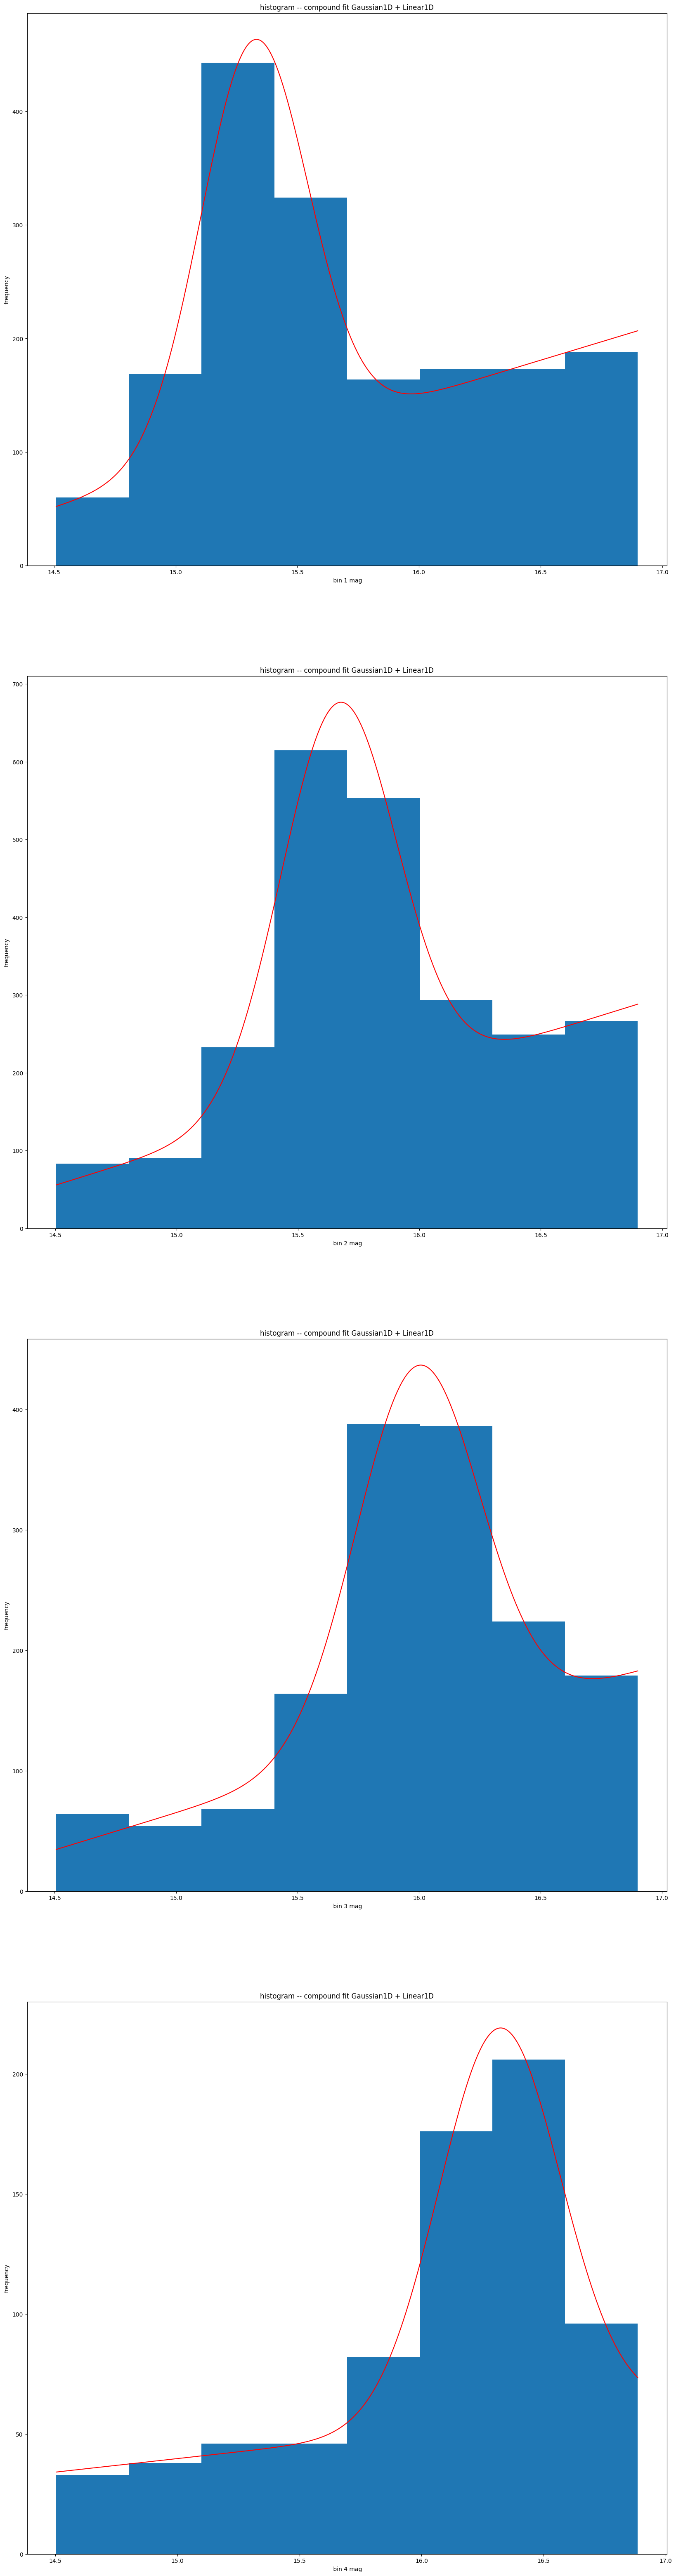

In [41]:
fig, axis = plt.subplots(4, 1, figsize = (20,80))

bin_heights1, bin_borders1 = np.histogram(bin1_y, bins=8)
bin_widths1 = np.diff(bin_borders1)
bin_centers1 = bin_borders1[:-1] + bin_widths1 / 2

t_init1 = models.Gaussian1D(345, 15.57, 0.7)
t_init21 = models.Linear1D(100, 100)
t_initf1 = t_init1 + t_init21

fit_t1 = fitting.LevMarLSQFitter()
t1 = fit_t1(t_initf1, bin_centers1, bin_heights1)

x_interval_for_fit1 = np.linspace(bin_borders1[0], bin_borders1[-1], 10000)
axis[0].bar(bin_centers1, bin_heights1, width=bin_widths1, label='histogram')
axis[0].plot(x_interval_for_fit1, t1(x_interval_for_fit1), label='fit', c='red')

error1 = t1.stddev_0.value / math.sqrt(len(bin1_y))

bin_heights2, bin_borders2 = np.histogram(bin2_y, bins=8)
bin_widths2 = np.diff(bin_borders2)
bin_centers2 = bin_borders2[:-1] + bin_widths2 / 2

t_init2 = models.Gaussian1D(536.867, 15.8, 0.52)
t_init22 = models.Linear1D(100, 100)
t_initf2 = t_init2 + t_init22

fit_t2 = fitting.LevMarLSQFitter()
t2 = fit_t2(t_initf2, bin_centers2, bin_heights2)

x_interval_for_fit2 = np.linspace(bin_borders2[0], bin_borders2[-1], 10000)
axis[1].bar(bin_centers2, bin_heights2, width=bin_widths2, label='histogram')
axis[1].plot(x_interval_for_fit2, t2(x_interval_for_fit2), label='fit', c='red')

error2 = t2.stddev_0.value / math.sqrt(len(bin2_y))

bin_heights3, bin_borders3 = np.histogram(bin3_y, bins=8)
bin_widths3 = np.diff(bin_borders3)
bin_centers3 = bin_borders3[:-1] + bin_widths3 / 2

t_init3 = models.Gaussian1D(309, 16, 0.25)
t_init23 = models.Linear1D(100, 100)
t_initf3 = t_init3 + t_init23

fit_t3 = fitting.LevMarLSQFitter()
t3 = fit_t3(t_initf3, bin_centers3, bin_heights3)

x_interval_for_fit3 = np.linspace(bin_borders3[0], bin_borders3[-1], 10000)
axis[2].bar(bin_centers3, bin_heights3, width=bin_widths3, label='histogram')
axis[2].plot(x_interval_for_fit3, t3(x_interval_for_fit3), label='fit', c='red')

error3 = t3.stddev_0.value / math.sqrt(len(bin3_y))

bin_heights4, bin_borders4 = np.histogram(bin4_y, bins=8)
bin_widths4 = np.diff(bin_borders4)
bin_centers4 = bin_borders4[:-1] + bin_widths4 / 2

t_init4 = models.Gaussian1D(164, 16.3, 0.24)
t_init24 = models.Linear1D(100, 100)
t_initf4 = t_init4 + t_init24

fit_t4 = fitting.LevMarLSQFitter()
t4 = fit_t4(t_initf4, bin_centers4, bin_heights4)

x_interval_for_fit4 = np.linspace(bin_borders4[0], bin_borders4[-1], 10000)
axis[3].bar(bin_centers4, bin_heights4, width=bin_widths4, label='histogram')
axis[3].plot(x_interval_for_fit4, t4(x_interval_for_fit4), label='fit', c='red')

error4 = t4.stddev_0.value / math.sqrt(len(bin4_y))

for i in range(4): 
    axis[i].set_xlabel(f" bin {i+1} mag")
    axis[i].set_ylabel(f"frequency")
    axis[i].set_title(f"histogram -- compound fit Gaussian1D + Linear1D")

plt.savefig("bins.png")

In [44]:
def generate_isochrones(catalog1_name, catalog2_name,
                        logAge, AKs, AKs_step, dist, metallicity, mass, iso_dir
):
    
    evo_model = evolution.MISTv1()
    atm_func  = atmospheres.get_merged_atmosphere
    red_law   = reddening.RedLawFritz11(scale_lambda=2.166)
    filt_list = [catalog1_name, catalog2_name]

    AKs2 = AKs  + AKs_step
    AKs3 = AKs2 + AKs_step
    AKs4 = AKs3 + AKs_step
    AKs5 = AKs4 + AKs_step

    my_iso = synthetic.IsochronePhot(logAge, AKs, dist,
                                        metallicity,
                                        evo_model=evo_model, atm_func=atm_func,
                                        red_law=red_law, filters=filt_list,
                                        iso_dir=iso_dir)

    my_iso2 = synthetic.IsochronePhot(logAge, AKs2, dist, metallicity,
                                        evo_model=evo_model, atm_func=atm_func,
                                        red_law=red_law, filters=filt_list,
                                        iso_dir=iso_dir)

    my_iso3 = synthetic.IsochronePhot(logAge, AKs3, dist, metallicity,
                                        evo_model=evo_model, atm_func=atm_func,
                                        red_law=red_law, filters=filt_list,
                                        iso_dir=iso_dir)

    my_iso4 = synthetic.IsochronePhot(logAge, AKs4, dist, metallicity,
                                        evo_model=evo_model, atm_func=atm_func,
                                        red_law=red_law, filters=filt_list,
                                        iso_dir=iso_dir)

    my_iso5 = synthetic.IsochronePhot(logAge, AKs5, dist, metallicity,
                                        evo_model=evo_model, atm_func=atm_func,
                                        red_law=red_law, filters=filt_list,
                                        iso_dir=iso_dir)

    file_name = filt_list[0] + "_" + filt_list[1]

    dfy = pd.DataFrame(my_iso.points['phase'])
    dfy.to_csv(f"{iso_dir}" + f"spisea_iso{file_name}.csv")

    print('The columns in the isochrone table are:\
            {0}'.format(my_iso.points.keys()))


    idx = np.where( abs(my_iso.points['mass'] - 1.0) == min(abs(my_iso.points['mass'] - 1.0)) )[0]
    filter_1 = np.round(my_iso.points[idx[0]][''+my_iso.points.keys()[9]], decimals=3)
    filter_2 = np.round(my_iso.points[idx[0]][''+my_iso.points.keys()[8]], decimals=3)

    idx2 = np.where( abs(my_iso2.points['mass'] - 1.0) == min(abs(my_iso2.points['mass'] - 1.0)) )[0]
    filter1_2 = np.round(my_iso2.points[idx2[0]][''+my_iso2.points.keys()[9]], decimals=3)
    filter2_2 = np.round(my_iso2.points[idx2[0]][''+my_iso2.points.keys()[8]], decimals=3)

    idx3 = np.where( abs(my_iso3.points['mass'] - 1.0) == min(abs(my_iso3.points['mass'] - 1.0)) )[0]
    filter1_3 = np.round(my_iso3.points[idx3[0]][''+my_iso3.points.keys()[9]], decimals=3)
    filter2_3 = np.round(my_iso3.points[idx3[0]][''+my_iso3.points.keys()[8]], decimals=3)

    idx4 = np.where( abs(my_iso4.points['mass'] - 1.0) == min(abs(my_iso4.points['mass'] - 1.0)) )[0]
    filter1_4 = np.round(my_iso4.points[idx4[0]][''+my_iso4.points.keys()[9]], decimals=3)
    filter2_4 = np.round(my_iso4.points[idx4[0]][''+my_iso4.points.keys()[8]], decimals=3)

    idx5 = np.where( abs(my_iso5.points['mass'] - 1.0) == min(abs(my_iso5.points['mass'] - 1.0)) )[0]
    filter1_5 = np.round(my_iso5.points[idx5[0]][''+my_iso5.points.keys()[9]], decimals=3)
    filter2_5 = np.round(my_iso5.points[idx5[0]][''+my_iso5.points.keys()[8]], decimals=3)

    print('1 M_sun: {0} = {1} mag, {2} = {3}\
            mag'.format(catalog1_name, filter_1, catalog2_name,
            filter_2))


    return my_iso, my_iso2, my_iso3, my_iso4, my_iso5, idx, idx2, idx3, idx4, idx5



In [45]:
my_iso, my_iso2, my_iso3, my_iso4, my_iso5, idx, idx2, idx3, idx4, idx5 = generate_isochrones(catalog1_name = 'jwst,F115W', catalog2_name = 'jwst,F212N',  logAge = np.log(10**9), AKs = 2, AKs_step = 0.25, dist = 8000, metallicity = -0.3, mass = 10**5, iso_dir = "/Users/devaldeliwala/research/jwst/isochrones/")

The columns in the isochrone table are:            ['L', 'Teff', 'R', 'mass', 'logg', 'isWR', 'mass_current', 'phase', 'm_jwst_F115W', 'm_jwst_F212N']
1 M_sun: jwst,F115W = 27.076 mag, jwst,F212N = 32.234            mag


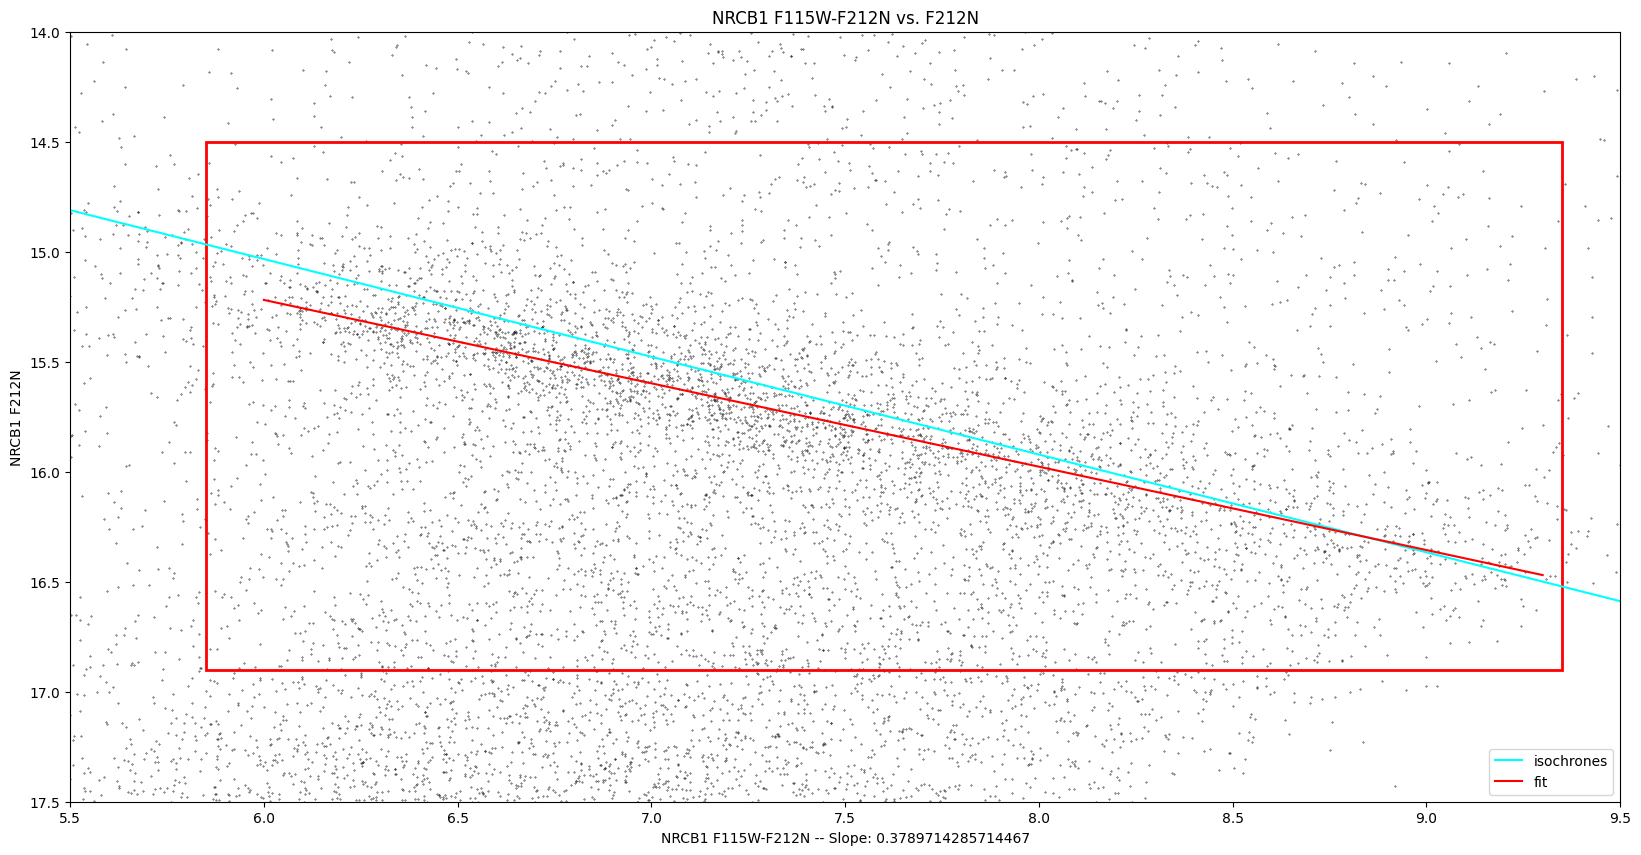

In [52]:
fig, axis = plt.subplots(1,1, figsize = (20, 10))

axis.axline((my_iso5.points[''+my_iso5.points.keys()[8]][idx5][0]
        - my_iso5.points[''+my_iso5.points.keys()[9]][idx5][0] - 3, 
        my_iso5.points[''+my_iso5.points.keys()[9]][idx5][0] - 13.75), 
        (my_iso.points[''+my_iso.points.keys()[8]][idx][0]
        - my_iso.points[''+my_iso.points.keys()[9]][idx][0] - 3,
        my_iso.points[''+my_iso.points.keys()[9]][idx][0] - 13.75), 
        color = 'aqua', label = 'isochrones'
)

plt.scatter(np.subtract(N1_f115w_vf212n, N1_f212n_vf115w), N1_f212n_vf115w, c = 'k', s = 0.1)


cutoff = Rectangle((5.85, 14.5), 3.5, 2.4, facecolor = (1, 0, 0, 0), lw = 2, ec = (1, 0, 0, 1))
axis.add_patch(cutoff)

x = np.subtract(N1_f115w_vf212n, N1_f212n_vf115w)
y = N1_f212n_vf115w
mag_idxs = []

filt1 = []
filt2 = []

for i in range(len(x)): 
    if x[i] > 5.85 and x[i] < 5.85 + 3.5:
        if y[i] > 14.5 and y[i] < 14.5 + 2.4: 
            mag_idxs.append(i)

for i in mag_idxs: 
    filt1.append(x[i])
    filt2.append(y[i])

plt.plot(x_interval_for_fit, t(x_interval_for_fit), label='fit', c='r')
plt.xlim(5.5, 9.5)
plt.ylim(17.5, 14)

plt.xlabel(f'NRCB1 F115W-F212N -- Slope: {t.slope.value}')
plt.ylabel('NRCB1 F212N')
plt.title('NRCB1 F115W-F212N vs. F212N')
plt.legend()


plt.savefig("bincmd.png")